In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet,ElasticNetCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.compose import ColumnTransformer
np.random.seed(42)

In [ ]:
df = pd.read_csv('/content/Housing.csv')

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
print(df.isna().sum())
print((df[['parking']]==0).sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
parking    299
dtype: int64


In [ ]:
df.info()
X = df.drop("price", axis=1)
y = df["price"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
num_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
cat_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(drop='first'), cat_columns)
    ])

In [ ]:
#Eğitim, Test Ayrımı ve Özellik Ölçekleme

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim seti boyutu nedir: ", X_train.shape)
print("Test seti boyutu nedir: ", X_test.shape)

Eğitim seti boyutu nedir:  (436, 12)
Test seti boyutu nedir:  (109, 12)


In [ ]:
alphas = np.logspace(-4, 4,100)

**Ridge Regresyon (L2 Regularizasyon)**

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Ridge', Ridge(alpha=1))])

In [ ]:
ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred))
print("Ridge MSE:", mean_squared_error(y_test, y_pred))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred))

Ridge R2: 0.6520909242049431
Ridge MSE: 1758530862952.2085
Ridge MAE: 971370.2374030846


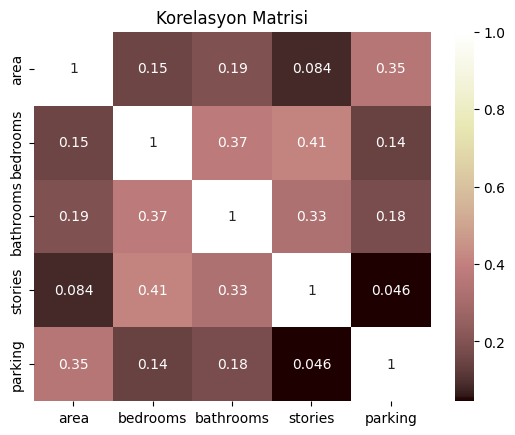

In [ ]:
corr_matrix =df[num_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='pink')
plt.title('Korelasyon Matrisi')
plt.show()

In [ ]:
alphas = np.logspace(-3, 3, 10)

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Ridge', RidgeCV(alphas=alphas,cv=5))])

In [ ]:
ridge_pipeline.fit(X_train, y_train)

# RidgeCV tarafından bulunan en iyi alpha değerini alın
best_alpha_ridgecv = ridge_pipeline.named_steps['Ridge'].alpha_
print("RidgeCV tarafından bulunan en iyi alpha değeri:", best_alpha_ridgecv)

y_pred_ridgecv = ridge_pipeline.predict(X_test)

print("RidgeCV R2:", r2_score(y_test, y_pred_ridgecv))
print("RidgeCV MSE:", mean_squared_error(y_test, y_pred_ridgecv))
print("RidgeCV MAE:", mean_absolute_error(y_test, y_pred_ridgecv))

RidgeCV tarafından bulunan en iyi alpha değeri: 10.0
RidgeCV R2: 0.6454739045516407
RidgeCV MSE: 1791977053611.3684
RidgeCV MAE: 979663.5036785456


**Lasso Regresyon (L1 Reguzarizasyon)**

In [ ]:
lasso_pipeline_cv = Pipeline(steps=[
    ('Preprocessor', preprocessor),
    ('Lasso', LassoCV(alphas=alphas, cv=5, random_state=42))
])

lasso_pipeline_cv.fit(X_train, y_train)

best_alpha_lassocv = lasso_pipeline_cv.named_steps['Lasso'].alpha_
print("LassoCV tarafından bulunan en iyi alpha değeri:", best_alpha_lassocv)

y_pred_lassocv = lasso_pipeline_cv.predict(X_test)

print("LassoCV R2:", r2_score(y_test, y_pred_lassocv))
print("LassoCV MSE:", mean_squared_error(y_test, y_pred_lassocv))
print("LassoCV MAE:", mean_absolute_error(y_test, y_pred_lassocv))

LassoCV tarafından bulunan en iyi alpha değeri: 0.001
LassoCV R2: 0.6529242636016104
LassoCV MSE: 1754318690432.6943
LassoCV MAE: 970043.4045527241


In [ ]:
from sklearn.linear_model import LassoCV
lassocv_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('Lasso', LassoCV(alphas=alphas,cv=5))])

In [ ]:
lassocv_pipeline.fit(X_train, y_train)

best_alpha_lassocv_new = lassocv_pipeline.named_steps['Lasso'].alpha_
print("LassoCV tarafından bulunan en iyi alpha değeri:", best_alpha_lassocv_new)

y_pred_lassocv_new = lassocv_pipeline.predict(X_test)

print("LassoCV R2:", r2_score(y_test, y_pred_lassocv_new))
print("LassoCV MSE:", mean_squared_error(y_test, y_pred_lassocv_new))
print("LassoCV MAE:", mean_absolute_error(y_test, y_pred_lassocv_new))

LassoCV tarafından bulunan en iyi alpha değeri: 0.001
LassoCV R2: 0.6529242636016104
LassoCV MSE: 1754318690432.6943
LassoCV MAE: 970043.4045527241


In [ ]:
lassocv_pipeline.fit(X_train, y_train)
best_alpha_lasso=lassocv_pipeline.named_steps['Lasso'].alpha_

In [ ]:
print("Best alpha:", best_alpha_lasso)

Best alpha: 0.001


**Elastic Net Regresyon(L1+L2)**

In [ ]:
elasticnet_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('ElasticNet', ElasticNet(alpha=1, l1_ratio=0.5,max_iter=1000))])

In [ ]:
elasticnet_pipeline.fit(X_train, y_train)
y_pred_elasticnet = elasticnet_pipeline.predict(X_test)

print("ElasticNet R2:", r2_score(y_test, y_pred_elasticnet))
print("ElasticNet MSE:", mean_squared_error(y_test, y_pred_elasticnet))
print("ElasticNet MAE:", mean_absolute_error(y_test, y_pred_elasticnet))

ElasticNet R2: 0.5500488157464565
ElasticNet MSE: 2274309868242.2876
ElasticNet MAE: 1110583.1438212262


In [ ]:
# ElasticNetCV ile hiperparametre ayarı yapılır

elasticnetcv_pipeline = Pipeline(steps=[
    ('Preprocessor', preprocessor),
    ('ElasticNet', ElasticNetCV(alphas=alphas, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, random_state=42, max_iter=1000))
])

elasticnetcv_pipeline.fit(X_train, y_train)

best_alpha_elasticnetcv = elasticnetcv_pipeline.named_steps['ElasticNet'].alpha_
best_l1_ratio_elasticnetcv = elasticnetcv_pipeline.named_steps['ElasticNet'].l1_ratio_

print(f"ElasticNetCV tarafından bulunan en iyi alpha değeri: {best_alpha_elasticnetcv}")
print(f"ElasticNetCV tarafından bulunan en iyi l1_ratio değeri: {best_l1_ratio_elasticnetcv}")

y_pred_elasticnetcv = elasticnetcv_pipeline.predict(X_test)

print("ElasticNetCV R2:", r2_score(y_test, y_pred_elasticnetcv))
print("ElasticNetCV MSE:", mean_squared_error(y_test, y_pred_elasticnetcv))
print("ElasticNetCV MAE:", mean_absolute_error(y_test, y_pred_elasticnetcv))

ElasticNetCV tarafından bulunan en iyi alpha değeri: 0.021544346900318832
ElasticNetCV tarafından bulunan en iyi l1_ratio değeri: 0.1
ElasticNetCV R2: 0.6465250813219998
ElasticNetCV MSE: 1786663806784.2463
ElasticNetCV MAE: 978434.2608550804


In [ ]:
elasticnet_pipeline = Pipeline(steps=[
    ('Preprocessor' ,preprocessor),
    ('ElasticNet', ElasticNet(alpha=1, l1_ratio=0.5,max_iter=1000))])

In [ ]:
elasticnet_pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('ElasticNet', ElasticNet(alpha=1))])

In [ ]:
y_pred_elasticnet = elasticnet_pipeline.predict(X_test)

elastic_mse = mean_squared_error(y_test, y_pred_elasticnet)
elastic_mae = mean_absolute_error(y_test, y_pred_elasticnet)
print(f"ElasticNet -> MSE: {elastic_mse:.2f} | MAE: {elastic_mae:.2f}")
elastic_r2 = r2_score(y_test, y_pred_elasticnet)
print(f"ElasticNet -> R2: {elastic_r2:.4f}")

ElasticNet -> MSE: 2274309868242.29 | MAE: 1110583.14
ElasticNet -> R2: 0.5500


**Modelleri Karşılaştıralım**

In [ ]:
ridge_r2 = r2_score(y_test, y_pred)
ridge_mse = mean_squared_error(y_test, y_pred)
ridge_mae = mean_absolute_error(y_test, y_pred)

sonuclar = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "MSE": [ridge_mse, lasso_mse, elastic_mse],
    "MAE": [ridge_mae, lasso_mae, elastic_mae],
    "R2": [ridge_r2, lasso_r2, elastic_r2]
})

sonuclar = sonuclar.sort_values("R2", ascending=False)
sonuclar

,Model,MSE,MAE,R2
0,Ridge,1.758531e+12,9.713702e+05,0.652091
2,ElasticNet,2.274310e+12,1.110583e+06,0.550049
1,Lasso,3.764233e+12,1.331489e+06,0.041924


In [ ]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished
